## Step 1: Load Inputs and Validate the In-Sample Backtest Setup

This notebook performs an **in-sample static portfolio backtest**. It is the evaluation step after static optimization in notebook 06 and the baseline before the rolling / out-of-sample backtest in notebook 08.

This notebook does **not**:
- optimize portfolios
- run a rolling / walk-forward process
- provide an out-of-sample evaluation

Inputs:
- `return_matrix_clean.csv`
- `portfolio_weights_static.csv`
- `portfolio_weights_aggressive.csv`

Interpretation of inputs:
- `portfolio_weights_static.csv` is the current canonical GMV / defensive output from notebook 06.
- `portfolio_weights_aggressive.csv` is currently a **legacy artifact** under the new feasibility gate in notebook 06.
- If the aggressive portfolio is still shown here, it should be interpreted as a **legacy, non-canonical comparison** only.

Backtest convention:
- Asset returns in `return_matrix_clean.csv` are log-returns.
- This notebook converts them to simple returns and evaluates a **constant-weight, daily rebalanced portfolio path**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

TRADING_DAYS = 252
DISPLAY_THRESHOLD = 0.001
SUM_TOL = 1e-6
WEIGHT_TOL = 1e-5
RISK_FREE_RATE = 0.0

GMV_LABEL = "GMV / Defensive (Canonical)"
AGG_LABEL = "Aggressive"
EQ_LABEL = "Equal-Weight Benchmark"
GMV_FIG_LABEL = "Danh mục GMV Defensive"
EQ_FIG_LABEL = "Danh mục Equal-Weight"

print("Imports, plotting configuration, and backtest constants are ready.")


Imports, plotting configuration, and backtest constants are ready.


In [2]:
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
HELPERS_DIR = PROJECT_ROOT / "notebooks" / "helpers"
if str(HELPERS_DIR) not in sys.path:
    sys.path.insert(0, str(HELPERS_DIR))

from static_artifact_contract import load_static_artifact_status, resolve_aggressive_input

REPORTS_BACKTEST_STATIC = PROJECT_ROOT / "reports" / "backtest_static"
REPORTS_BACKTEST_STATIC_FIG = REPORTS_BACKTEST_STATIC / "figures"
REPORTS_BACKTEST_STATIC_FIG.mkdir(parents=True, exist_ok=True)

STATUS_PATH = DATA_PROCESSED / "static_artifact_status.json"
AGG_CANONICAL_PATH = DATA_PROCESSED / "portfolio_weights_aggressive.csv"
AGG_LEGACY_PATH = DATA_PROCESSED / "legacy" / "portfolio_weights_aggressive_prefeasibility.csv"
ALLOW_LEGACY_AGG = False

print("=" * 72)
print("LOAD AND VALIDATE INPUTS")
print("=" * 72)

ret = pd.read_csv(
    DATA_PROCESSED / "return_matrix_clean.csv", index_col=0, parse_dates=True
)
weights_gmv = pd.read_csv(DATA_PROCESSED / "portfolio_weights_static.csv")
status = load_static_artifact_status(STATUS_PATH)
weights_agg_path, agg_status_text, agg_mode = resolve_aggressive_input(
    status=status,
    canonical_path=AGG_CANONICAL_PATH,
    legacy_path=AGG_LEGACY_PATH,
    allow_legacy=ALLOW_LEGACY_AGG,
)
weights_agg = pd.read_csv(weights_agg_path) if weights_agg_path is not None else None
agg_available = weights_agg is not None
AGG_LABEL = {
    "canonical": "Aggressive (Canonical)",
    "legacy": "Aggressive (LEGACY)",
    "unavailable": "Aggressive (Unavailable)",
}.get(agg_mode, "Aggressive")
AGG_FIG_LABEL = {
    "canonical": "Danh mục Aggressive",
    "legacy": "Danh mục Aggressive (LEGACY)",
    "unavailable": "Danh mục Aggressive (không khả dụng)",
}.get(agg_mode, "Aggressive")

assert ret.shape[0] > 0 and ret.shape[1] > 0, "return_matrix_clean.csv is empty"
assert weights_gmv.shape[0] > 0, "portfolio_weights_static.csv is empty"
assert ret.columns.is_unique, "Duplicate tickers found in the return matrix"

ret.columns = ret.columns.str.upper().str.strip()
ret = ret.sort_index()
assert ret.notna().all().all(), "Return matrix contains NaN values"

required_weight_cols = {"ticker", "weight"}
for label, df in {GMV_LABEL: weights_gmv}.items():
    missing_cols = required_weight_cols - set(df.columns)
    assert not missing_cols, f"{label} is missing required columns: {sorted(missing_cols)}"
    df["ticker"] = df["ticker"].astype(str).str.upper().str.strip()
    df["weight"] = pd.to_numeric(df["weight"], errors="raise")
    assert df["ticker"].notna().all(), f"{label} contains missing tickers"
    assert df["weight"].notna().all(), f"{label} contains missing weights"
    duplicate_tickers = df.loc[df["ticker"].duplicated(), "ticker"].tolist()
    assert not duplicate_tickers, f"{label} has duplicate tickers: {duplicate_tickers}"

assert set(weights_gmv["ticker"]) == set(ret.columns), (
    "Ticker universe mismatch between return_matrix_clean.csv and portfolio_weights_static.csv"
)

if weights_agg is not None:
    assert weights_agg.shape[0] > 0, "portfolio_weights_aggressive.csv is empty"
    missing_cols = required_weight_cols - set(weights_agg.columns)
    assert not missing_cols, f"{AGG_LABEL} is missing required columns: {sorted(missing_cols)}"
    weights_agg["ticker"] = weights_agg["ticker"].astype(str).str.upper().str.strip()
    weights_agg["weight"] = pd.to_numeric(weights_agg["weight"], errors="raise")
    assert weights_agg["ticker"].notna().all(), f"{AGG_LABEL} contains missing tickers"
    assert weights_agg["weight"].notna().all(), f"{AGG_LABEL} contains missing weights"
    duplicate_tickers = weights_agg.loc[weights_agg["ticker"].duplicated(), "ticker"].tolist()
    assert not duplicate_tickers, f"{AGG_LABEL} has duplicate tickers: {duplicate_tickers}"
    assert set(weights_agg["ticker"]) == set(ret.columns), (
        "Ticker universe mismatch between return_matrix_clean.csv and portfolio_weights_aggressive.csv"
    )

print(f"Return matrix shape:        {ret.shape}")
print(f"Return period:              {ret.index[0].date()} to {ret.index[-1].date()}")
print(f"GMV weights shape:          {weights_gmv.shape}")
if weights_agg is not None:
    print(f"Aggressive weights shape:   {weights_agg.shape}")
else:
    print("Aggressive unavailable under the current manifest/policy. This notebook is running in safe mode: GMV + Equal-Weight only.")
print(f"Ticker universe size:       {len(ret.columns)}")
print(f"Report figure directory:    {REPORTS_BACKTEST_STATIC_FIG}")
print()
print(f"{GMV_LABEL}: current canonical clean artifact from notebook 06")
if weights_agg is not None:
    if agg_mode == "legacy":
        print("Aggressive is being shown as a LEGACY / non-canonical reference only.")
    else:
        print("Aggressive is available as a canonical strategy in this run.")
print("All structural input validation checks passed.")


LOAD AND VALIDATE INPUTS
Return matrix shape:        (1435, 29)
Return period:              2020-01-03 to 2025-11-28
GMV weights shape:          (29, 5)
Aggressive weights shape:   (29, 5)
Ticker universe size:       29
Report figure directory:    D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\backtest_static\figures

GMV / Defensive (Canonical): current canonical clean artifact from notebook 06
Aggressive is available as a canonical strategy in this run.
All structural input validation checks passed.


## Step 2: Build Aligned Weight Vectors and Validate Portfolio Inputs

This section aligns the weight files with the backtest universe **without silent zero-filling** for the optimizer outputs.

Validation focus:
- exact ticker-universe alignment
- no missing weights after alignment
- clean GMV weight vector status
- clear legacy labeling for the aggressive artifact


In [3]:
print("=" * 72)
print("BUILD AND VALIDATE WEIGHT VECTORS")
print("=" * 72)

def validate_weight_vector(label, weights, artifact_status):
    validation = {
        "artifact_status": artifact_status,
        "sum_weights": float(weights.sum()),
        "weight_sum_error": float(abs(weights.sum() - 1.0)),
        "n_nan_weights": int(np.isnan(weights).sum()),
        "min_weight": float(weights.min()),
        "max_weight": float(weights.max()),
        "gross_exposure": float(np.abs(weights).sum()),
        "display_holdings": int((weights > DISPLAY_THRESHOLD).sum()),
        "n_negative_beyond_tol": int((weights < -WEIGHT_TOL).sum()),
    }
    validation["clean_long_only"] = (
        validation["n_nan_weights"] == 0
        and validation["weight_sum_error"] <= SUM_TOL
        and validation["n_negative_beyond_tol"] == 0
    )

    print(f"\n{label}:")
    print(f"  - Artifact status:          {artifact_status}")
    print(f"  - Vector shape:             {weights.shape}")
    print(f"  - Sum of weights:           {validation['sum_weights']:.8f}")
    print(f"  - Weight sum error:         {validation['weight_sum_error']:.8f}")
    print(f"  - Min weight:               {validation['min_weight']:.8f}")
    print(f"  - Max weight:               {validation['max_weight']:.8f}")
    print(f"  - Negative weights < -tol:  {validation['n_negative_beyond_tol']}")
    print(f"  - Gross exposure:           {validation['gross_exposure']:.8f}")
    print(f"  - Holdings > 0.1%:          {validation['display_holdings']}")
    print(f"  - Clean long-only status:   {'PASS' if validation['clean_long_only'] else 'FAIL'}")

    return validation

gmv_aligned = weights_gmv.set_index("ticker").reindex(ret.columns)
assert gmv_aligned["weight"].notna().all(), "Missing aligned GMV weights after ticker reindex"
assert list(gmv_aligned.index) == list(ret.columns), "GMV weights are not aligned with the backtest universe"

w_gmv = gmv_aligned["weight"].to_numpy(dtype=float)
w_eq = np.full(ret.shape[1], 1.0 / ret.shape[1], dtype=float)

gmv_weight_validation = validate_weight_vector(GMV_LABEL, w_gmv, "Canonical clean artifact")
eq_weight_validation = validate_weight_vector(EQ_LABEL, w_eq, "Benchmark")

if weights_agg is not None:
    agg_aligned = weights_agg.set_index("ticker").reindex(ret.columns)
    assert agg_aligned["weight"].notna().all(), "Missing aligned aggressive weights after ticker reindex"
    assert list(agg_aligned.index) == list(ret.columns), "Aggressive weights are not aligned with the backtest universe"
    w_agg = agg_aligned["weight"].to_numpy(dtype=float)
    agg_weight_validation = validate_weight_vector(AGG_LABEL, w_agg, agg_status_text)
else:
    agg_aligned = None
    w_agg = None
    agg_weight_validation = None
    print("\nAggressive unavailable under the current manifest/policy. This notebook is running in safe mode: GMV + Equal-Weight only.")

if gmv_weight_validation["clean_long_only"]:
    print("\nGMV / Defensive remains a clean canonical backtest input under the current notebook 06 gate.")
else:
    print("\nGMV / Defensive does not pass clean-weight validation and must not be treated as a clean canonical backtest.")

if agg_weight_validation is not None:
    if agg_weight_validation["clean_long_only"]:
        if agg_mode == "legacy":
            print("Aggressive passes the simple weight checks numerically, but it is still a LEGACY artifact under notebook 07.")
        else:
            print("Aggressive is available as a canonical strategy in this run.")
    else:
        print("Aggressive fails clean-weight validation and remains non-canonical.")

print("\nTop 5 GMV holdings by weight:")
print(gmv_aligned.reset_index().rename(columns={"index": "ticker"}).sort_values("weight", ascending=False).head(5)[["ticker", "weight"]].to_string(index=False))

if agg_aligned is not None:
    top_agg = agg_aligned.reset_index().rename(columns={"index": "ticker"}).sort_values("weight", ascending=False).head(5)
    print("\nTop 5 aggressive holdings by weight:")
    print(top_agg[["ticker", "weight"]].to_string(index=False))


BUILD AND VALIDATE WEIGHT VECTORS

GMV / Defensive (Canonical):
  - Artifact status:          Canonical clean artifact
  - Vector shape:             (29,)
  - Sum of weights:           1.00000000
  - Weight sum error:         0.00000000
  - Min weight:               -0.00000000
  - Max weight:               0.18895881
  - Negative weights < -tol:  0
  - Gross exposure:           1.00000000
  - Holdings > 0.1%:          15
  - Clean long-only status:   PASS

Equal-Weight Benchmark:
  - Artifact status:          Benchmark
  - Vector shape:             (29,)
  - Sum of weights:           1.00000000
  - Weight sum error:         0.00000000
  - Min weight:               0.03448276
  - Max weight:               0.03448276
  - Negative weights < -tol:  0
  - Gross exposure:           1.00000000
  - Holdings > 0.1%:          29
  - Clean long-only status:   PASS

Aggressive (Canonical):
  - Artifact status:          Canonical aggressive artifact
  - Vector shape:             (29,)
  - Sum of w

## Step 3: Compute Daily Portfolio Returns on Simple Returns

`return_matrix_clean.csv` stores **asset log-returns**. To keep the backtest financially consistent for a **constant-weight, daily rebalanced portfolio**, this notebook converts asset log-returns to simple returns first:

- `simple_ret = exp(log_ret) - 1`
- `r_p,t = sum_i w_i * r_i,t`

The same convention is applied to:
- GMV / Defensive (canonical)
- Aggressive (legacy comparison)
- Equal-weight benchmark


In [4]:
print("=" * 72)
print("COMPUTE DAILY SIMPLE PORTFOLIO RETURNS")
print("=" * 72)

simple_ret = np.exp(ret) - 1
assert np.isfinite(simple_ret.to_numpy()).all(), "Simple return matrix contains non-finite values"

ret_gmv = pd.Series(simple_ret.to_numpy() @ w_gmv, index=simple_ret.index, name=GMV_LABEL)
ret_eq = pd.Series(simple_ret.to_numpy() @ w_eq, index=simple_ret.index, name=EQ_LABEL)
ret_agg = pd.Series(simple_ret.to_numpy() @ w_agg, index=simple_ret.index, name=AGG_LABEL) if w_agg is not None else None

for label, series in [(GMV_LABEL, ret_gmv), (EQ_LABEL, ret_eq)] + ([(AGG_LABEL, ret_agg)] if ret_agg is not None else []):
    print(f"\n{label}:")
    print(f"  - Mean daily simple return: {series.mean():.6f} ({series.mean() * 100:.4f}%)")
    print(f"  - Std daily simple return:  {series.std():.6f} ({series.std() * 100:.4f}%)")
    print(f"  - Min daily simple return:  {series.min():.6f} ({series.min() * 100:.4f}%)")
    print(f"  - Max daily simple return:  {series.max():.6f} ({series.max() * 100:.4f}%)")

if ret_agg is None:
    print("\nAggressive simple returns are skipped in safe mode.")
else:
    print("\nDaily portfolio returns are now computed on simple returns for a constant-weight rebalanced path.")


COMPUTE DAILY SIMPLE PORTFOLIO RETURNS

GMV / Defensive (Canonical):
  - Mean daily simple return: 0.000528 (0.0528%)
  - Std daily simple return:  0.011887 (1.1887%)
  - Min daily simple return:  -0.126409 (-12.6409%)
  - Max daily simple return:  0.069035 (6.9035%)

Equal-Weight Benchmark:
  - Mean daily simple return: 0.000938 (0.0938%)
  - Std daily simple return:  0.014899 (1.4899%)
  - Min daily simple return:  -0.162333 (-16.2333%)
  - Max daily simple return:  0.068961 (6.8961%)

Aggressive (Canonical):
  - Mean daily simple return: 0.002169 (0.2169%)
  - Std daily simple return:  0.020173 (2.0173%)
  - Min daily simple return:  -0.128526 (-12.8526%)
  - Max daily simple return:  0.081917 (8.1917%)

Daily portfolio returns are now computed on simple returns for a constant-weight rebalanced path.


## Step 4: Build NAV for a Constant-Weight Rebalanced Portfolio

With daily portfolio simple returns in hand, the notebook builds NAV as a growth path:

- `NAV_t = NAV_{t-1} * (1 + r_p,t)`

Interpretation:
- the base NAV **before** the first observed return is `1.0`
- the plotted series is a **constant-weight rebalanced portfolio path**
- this is **not** a buy-and-hold share path


In [5]:
print("=" * 72)
print("BUILD NAV AND CUMULATIVE PERFORMANCE SERIES")
print("=" * 72)

nav_gmv = (1 + ret_gmv).cumprod()
nav_eq = (1 + ret_eq).cumprod()
nav_agg = (1 + ret_agg).cumprod() if ret_agg is not None else None

print("Base NAV before the first observed return: 1.0000")

for label, nav in [(GMV_LABEL, nav_gmv), (EQ_LABEL, nav_eq)] + ([(AGG_LABEL, nav_agg)] if nav_agg is not None else []):
    print(f"\n{label}:")
    print(f"  - First observed NAV: {nav.iloc[0]:.4f}")
    print(f"  - Final NAV:          {nav.iloc[-1]:.4f}")
    print(f"  - Total return:       {(nav.iloc[-1] - 1) * 100:.2f}%")

if nav_agg is None:
    print("\nAggressive NAV is skipped in safe mode.")
else:
    print("\nNAV series are built with (1 + daily portfolio return).cumprod().")


BUILD NAV AND CUMULATIVE PERFORMANCE SERIES
Base NAV before the first observed return: 1.0000

GMV / Defensive (Canonical):
  - First observed NAV: 0.9988
  - Final NAV:          1.9245
  - Total return:       92.45%

Equal-Weight Benchmark:
  - First observed NAV: 0.9980
  - Final NAV:          3.2670
  - Total return:       226.70%

Aggressive (Canonical):
  - First observed NAV: 0.9912
  - Final NAV:          16.7054
  - Total return:       1570.54%

NAV series are built with (1 + daily portfolio return).cumprod().


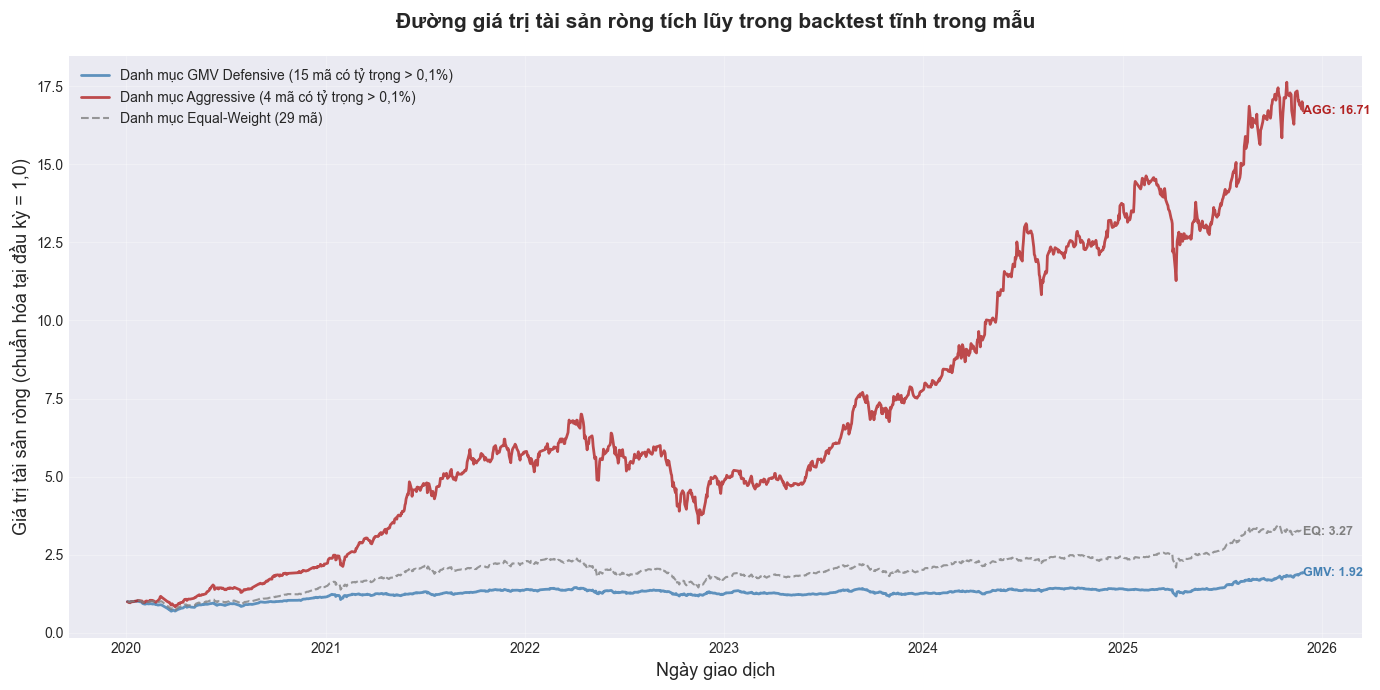

Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\backtest_static\figures\static_equity_curves.png


In [6]:
equity_curve_path = REPORTS_BACKTEST_STATIC_FIG / "static_equity_curves.png"

gmv_holdings_label = gmv_weight_validation["display_holdings"]
eq_holdings_label = eq_weight_validation["display_holdings"]
agg_holdings_label = agg_weight_validation["display_holdings"] if agg_weight_validation is not None else None

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    nav_gmv.index,
    nav_gmv.values,
    label=f"{GMV_FIG_LABEL} ({gmv_holdings_label} mã có tỷ trọng > 0,1%)",
    color="steelblue",
    linewidth=2,
    alpha=0.85,
)
if nav_agg is not None:
    ax.plot(
        nav_agg.index,
        nav_agg.values,
        label=f"{AGG_FIG_LABEL} ({agg_holdings_label} mã có tỷ trọng > 0,1%)",
        color="firebrick",
        linewidth=2,
        alpha=0.8,
    )
ax.plot(
    nav_eq.index,
    nav_eq.values,
    label=f"{EQ_FIG_LABEL} ({eq_holdings_label} mã)",
    color="gray",
    linewidth=1.5,
    linestyle="--",
    alpha=0.8,
)

ax.set_xlabel("Ngày giao dịch", fontsize=13)
ax.set_ylabel("Giá trị tài sản ròng (chuẩn hóa tại đầu kỳ = 1,0)", fontsize=13)
ax.set_title("Đường giá trị tài sản ròng tích lũy trong backtest tĩnh trong mẫu", fontsize=15, fontweight="bold", pad=20)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)

for nav, short_label, color in [
    (nav_gmv, "GMV", "steelblue"),
    (nav_eq, "EQ", "gray"),
] + ([(nav_agg, "AGG", "firebrick")] if nav_agg is not None else []):
    ax.text(
        nav.index[-1],
        nav.iloc[-1],
        f"{short_label}: {nav.iloc[-1]:.2f}",
        fontsize=9,
        fontweight="bold",
        color=color,
        verticalalignment="center",
        horizontalalignment="left",
    )

plt.tight_layout()
plt.savefig(equity_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {equity_curve_path}")


## Step 5: Compute Performance Metrics on the Revised Backtest Convention

The notebook reports:
- **Annualized Mean Return (%)** from daily portfolio simple returns
- **Annualized Volatility (%)** from daily portfolio simple returns
- **Sharpe Ratio (Rf = 0)**
- **Max Drawdown (%)** from the NAV path

These are descriptive **in-sample** metrics for the revised constant-weight rebalanced backtest. They are not out-of-sample claims.


In [7]:
print("=" * 72)
print("COMPUTE PERFORMANCE METRICS")
print("=" * 72)

def calculate_drawdown(nav):
    """Return the drawdown series based on the running high-water mark."""
    running_max = nav.cummax()
    return nav / running_max - 1


def calculate_metrics(returns, nav):
    """Compute annualized mean return, annualized volatility, Sharpe (Rf=0), and max drawdown."""
    mean_daily_ret = returns.mean()
    annualized_mean_return = mean_daily_ret * TRADING_DAYS
    daily_vol = returns.std()
    annualized_vol = daily_vol * np.sqrt(TRADING_DAYS)
    sharpe = (annualized_mean_return - RISK_FREE_RATE) / annualized_vol if annualized_vol > 0 else np.nan
    max_dd = calculate_drawdown(nav).min()

    return {
        "Annualized Mean Return (%)": annualized_mean_return * 100,
        "Annualized Volatility (%)": annualized_vol * 100,
        "Sharpe Ratio (Rf=0)": sharpe,
        "Max Drawdown (%)": max_dd * 100,
    }

metrics_gmv = calculate_metrics(ret_gmv, nav_gmv)
metrics_eq = calculate_metrics(ret_eq, nav_eq)
metrics_agg = calculate_metrics(ret_agg, nav_agg) if ret_agg is not None and nav_agg is not None else None

metrics_rows = [
    {
        "Strategy": GMV_LABEL,
        "Artifact Status": "Canonical clean artifact",
        "Clean Weight Validation": "PASS" if gmv_weight_validation["clean_long_only"] else "FAIL",
        **metrics_gmv,
    },
]
if metrics_agg is not None:
    metrics_rows.append(
        {
            "Strategy": AGG_LABEL,
            "Artifact Status": {
                "canonical": "Canonical aggressive artifact",
                "legacy": "LEGACY / non-canonical reference",
                "unavailable": "Unavailable under current manifest/policy",
            }.get(agg_mode, "Unavailable under current manifest/policy"),
            "Clean Weight Validation": "PASS" if agg_weight_validation["clean_long_only"] else "FAIL",
            **metrics_agg,
        }
    )
metrics_rows.append(
    {
        "Strategy": EQ_LABEL,
        "Artifact Status": "Benchmark",
        "Clean Weight Validation": "PASS" if eq_weight_validation["clean_long_only"] else "FAIL",
        **metrics_eq,
    }
)

metrics_df = pd.DataFrame(metrics_rows).set_index("Strategy")

print("Performance metrics table:")
print(metrics_df.to_string())


COMPUTE PERFORMANCE METRICS
Performance metrics table:
                                           Artifact Status Clean Weight Validation  Annualized Mean Return (%)  Annualized Volatility (%)  Sharpe Ratio (Rf=0)  Max Drawdown (%)
Strategy                                                                                                                                                                        
GMV / Defensive (Canonical)       Canonical clean artifact                    PASS                   13.299834                  18.869775             0.704822        -31.390808
Aggressive (Canonical)       Canonical aggressive artifact                    PASS                   54.649340                  32.023847             1.706520        -49.967256
Equal-Weight Benchmark                           Benchmark                    PASS                   23.640081                  23.651309             0.999525        -39.015747


## Step 6: Drawdown Analysis

Drawdown is computed on the revised NAV path using the standard high-water mark definition:

- `Drawdown_t = NAV_t / max(NAV_0 ... NAV_t) - 1`

This keeps the drawdown analysis aligned with the same simple-return backtest convention used above.


In [8]:
print("=" * 72)
print("COMPUTE DRAWDOWN SERIES")
print("=" * 72)

dd_gmv = calculate_drawdown(nav_gmv)
dd_eq = calculate_drawdown(nav_eq)
dd_agg = calculate_drawdown(nav_agg) if nav_agg is not None else None

for label, dd in [(GMV_LABEL, dd_gmv), (EQ_LABEL, dd_eq)] + ([(AGG_LABEL, dd_agg)] if dd_agg is not None else []):
    print(f"\n{label}:")
    print(f"  - Max drawdown: {dd.min() * 100:.2f}%")
    print(f"  - Max drawdown date: {dd.idxmin().date()}")

if dd_agg is None:
    print("\nAggressive drawdown analysis is skipped in safe mode.")
else:
    print("\nDrawdown analysis uses the same NAV path reported above.")


COMPUTE DRAWDOWN SERIES

GMV / Defensive (Canonical):
  - Max drawdown: -31.39%
  - Max drawdown date: 2020-03-24

Equal-Weight Benchmark:
  - Max drawdown: -39.02%
  - Max drawdown date: 2022-11-15

Aggressive (Canonical):
  - Max drawdown: -49.97%
  - Max drawdown date: 2022-11-15

Drawdown analysis uses the same NAV path reported above.


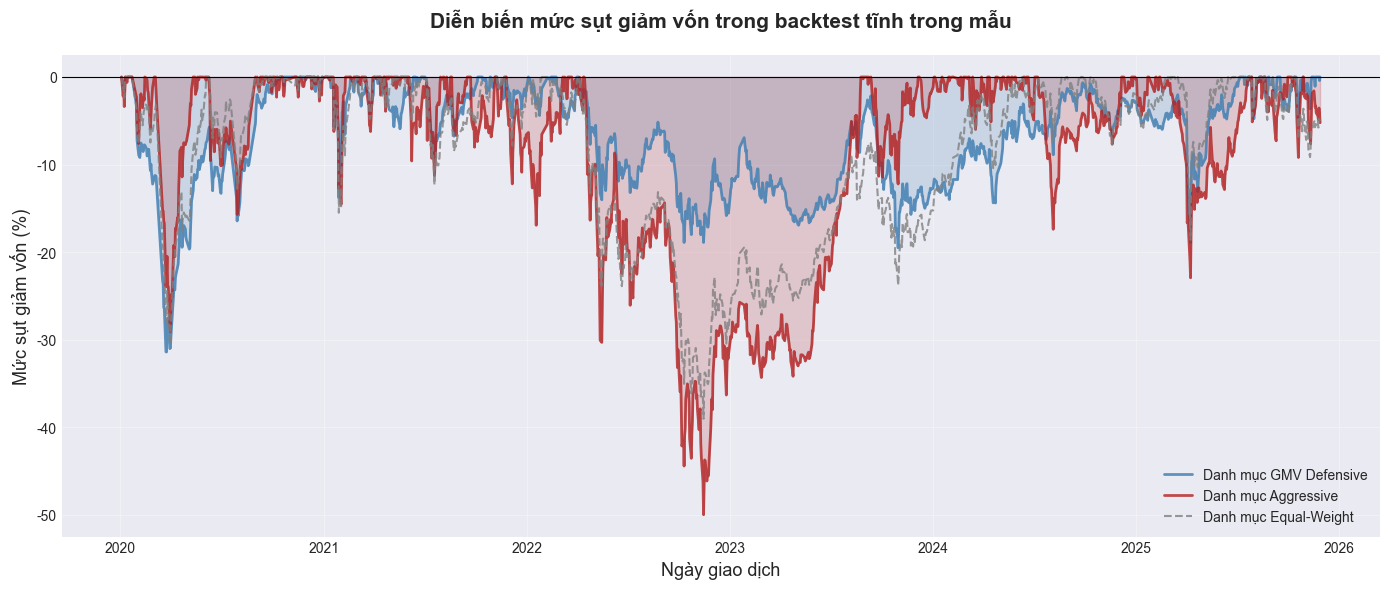

Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\backtest_static\figures\static_drawdown_curves.png


In [9]:
drawdown_curve_path = REPORTS_BACKTEST_STATIC_FIG / "static_drawdown_curves.png"

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dd_gmv.index, dd_gmv.values * 100, label=GMV_FIG_LABEL, color="steelblue", linewidth=2, alpha=0.85)
if dd_agg is not None:
    ax.plot(dd_agg.index, dd_agg.values * 100, label=AGG_FIG_LABEL, color="firebrick", linewidth=2, alpha=0.8)
ax.plot(dd_eq.index, dd_eq.values * 100, label=EQ_FIG_LABEL, color="gray", linewidth=1.5, linestyle="--", alpha=0.8)

ax.fill_between(dd_gmv.index, dd_gmv.values * 100, 0, alpha=0.2, color="steelblue")
if dd_agg is not None:
    ax.fill_between(dd_agg.index, dd_agg.values * 100, 0, alpha=0.18, color="firebrick")

ax.set_xlabel("Ngày giao dịch", fontsize=13)
ax.set_ylabel("Mức sụt giảm vốn (%)", fontsize=13)
ax.set_title("Diễn biến mức sụt giảm vốn trong backtest tĩnh trong mẫu", fontsize=15, fontweight="bold", pad=20)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)

plt.tight_layout()
plt.savefig(drawdown_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {drawdown_curve_path}")


## Step 7: Comparison, Interpretation, and Legacy Caveat

The comparison below keeps all three series visible, but interpretation must separate:
- **canonical findings**: GMV / Defensive vs the equal-weight benchmark
- **legacy reference**: Aggressive, which is still shown for historical comparison only

Aggressive should **not** be treated here as a clean canonical optimizer output under the current notebook 06 gate.


In [10]:
print("=" * 88)
print("DETAILED COMPARISON AND INTERPRETATION")
print("=" * 88)

print("\n1. Canonical baseline findings: GMV / Defensive vs Equal-Weight Benchmark")
print(f"   - {GMV_LABEL}:")
print(f"       Annualized mean return: {metrics_gmv['Annualized Mean Return (%)']:.2f}%")
print(f"       Annualized volatility:  {metrics_gmv['Annualized Volatility (%)']:.2f}%")
print(f"       Sharpe (Rf=0):          {metrics_gmv['Sharpe Ratio (Rf=0)']:.4f}")
print(f"       Max drawdown:           {metrics_gmv['Max Drawdown (%)']:.2f}%")
print(f"   - {EQ_LABEL}:")
print(f"       Annualized mean return: {metrics_eq['Annualized Mean Return (%)']:.2f}%")
print(f"       Annualized volatility:  {metrics_eq['Annualized Volatility (%)']:.2f}%")
print(f"       Sharpe (Rf=0):          {metrics_eq['Sharpe Ratio (Rf=0)']:.4f}")
print(f"       Max drawdown:           {metrics_eq['Max Drawdown (%)']:.2f}%")

vol_gap = metrics_eq['Annualized Volatility (%)'] - metrics_gmv['Annualized Volatility (%)']
dd_gap = metrics_gmv['Max Drawdown (%)'] - metrics_eq['Max Drawdown (%)']
ret_gap = metrics_gmv['Annualized Mean Return (%)'] - metrics_eq['Annualized Mean Return (%)']
sharpe_gap = metrics_gmv['Sharpe Ratio (Rf=0)'] - metrics_eq['Sharpe Ratio (Rf=0)']

print("\n   Canonical interpretation:")
print(f"   - Return gap (GMV - benchmark):      {ret_gap:+.2f}%")
print(f"   - Volatility gap (GMV - benchmark):  {-vol_gap:+.2f}%")
print(f"   - Sharpe gap (GMV - benchmark):      {sharpe_gap:+.4f}")
print(f"   - Drawdown gap (GMV - benchmark):    {dd_gap:+.2f}%")

if metrics_gmv['Annualized Volatility (%)'] < metrics_eq['Annualized Volatility (%)']:
    print("   - GMV lowers in-sample volatility relative to the benchmark.")
else:
    print("   - GMV does not lower in-sample volatility relative to the benchmark.")

if metrics_gmv['Max Drawdown (%)'] > metrics_eq['Max Drawdown (%)']:
    print("   - GMV improves max drawdown relative to the benchmark.")
else:
    print("   - GMV does not improve max drawdown relative to the benchmark.")

print("\n2. Aggressive comparison note")
if metrics_agg is not None:
    print(f"   - Artifact status:             {metrics_df.loc[AGG_LABEL, 'Artifact Status']}")
    print(f"   - Clean weight validation:     {metrics_df.loc[AGG_LABEL, 'Clean Weight Validation']}")
    print(f"   - Annualized mean return:      {metrics_agg['Annualized Mean Return (%)']:.2f}%")
    print(f"   - Annualized volatility:       {metrics_agg['Annualized Volatility (%)']:.2f}%")
    print(f"   - Sharpe (Rf=0):               {metrics_agg['Sharpe Ratio (Rf=0)']:.4f}")
    print(f"   - Max drawdown:                {metrics_agg['Max Drawdown (%)']:.2f}%")
    print(f"   - Gross exposure:              {agg_weight_validation['gross_exposure']:.4f}")
    print(f"   - Negative weights < -tol:     {agg_weight_validation['n_negative_beyond_tol']}")

    if agg_weight_validation['clean_long_only']:
        if agg_mode == "legacy":
            print("   - This aggressive series is shown as a LEGACY / non-canonical reference only.")
        else:
            print("   - This aggressive series is available as a canonical strategy in this run.")
    else:
        print("   - This aggressive series does not pass clean-weight validation and should not be presented as canonical.")
else:
    print("   - Aggressive unavailable under the current manifest/policy. This notebook is running in safe mode: GMV + Equal-Weight only.")

print("\n3. In-sample interpretation boundary")
print("   - All results in this notebook are in-sample and optimistic by construction.")
print("   - Notebook 08 is the next step for rolling / out-of-sample evaluation.")


DETAILED COMPARISON AND INTERPRETATION

1. Canonical baseline findings: GMV / Defensive vs Equal-Weight Benchmark
   - GMV / Defensive (Canonical):
       Annualized mean return: 13.30%
       Annualized volatility:  18.87%
       Sharpe (Rf=0):          0.7048
       Max drawdown:           -31.39%
   - Equal-Weight Benchmark:
       Annualized mean return: 23.64%
       Annualized volatility:  23.65%
       Sharpe (Rf=0):          0.9995
       Max drawdown:           -39.02%

   Canonical interpretation:
   - Return gap (GMV - benchmark):      -10.34%
   - Volatility gap (GMV - benchmark):  -4.78%
   - Sharpe gap (GMV - benchmark):      -0.2947
   - Drawdown gap (GMV - benchmark):    +7.62%
   - GMV lowers in-sample volatility relative to the benchmark.
   - GMV improves max drawdown relative to the benchmark.

2. Aggressive comparison note
   - Artifact status:             Canonical aggressive artifact
   - Clean weight validation:     PASS
   - Annualized mean return:      54.65%


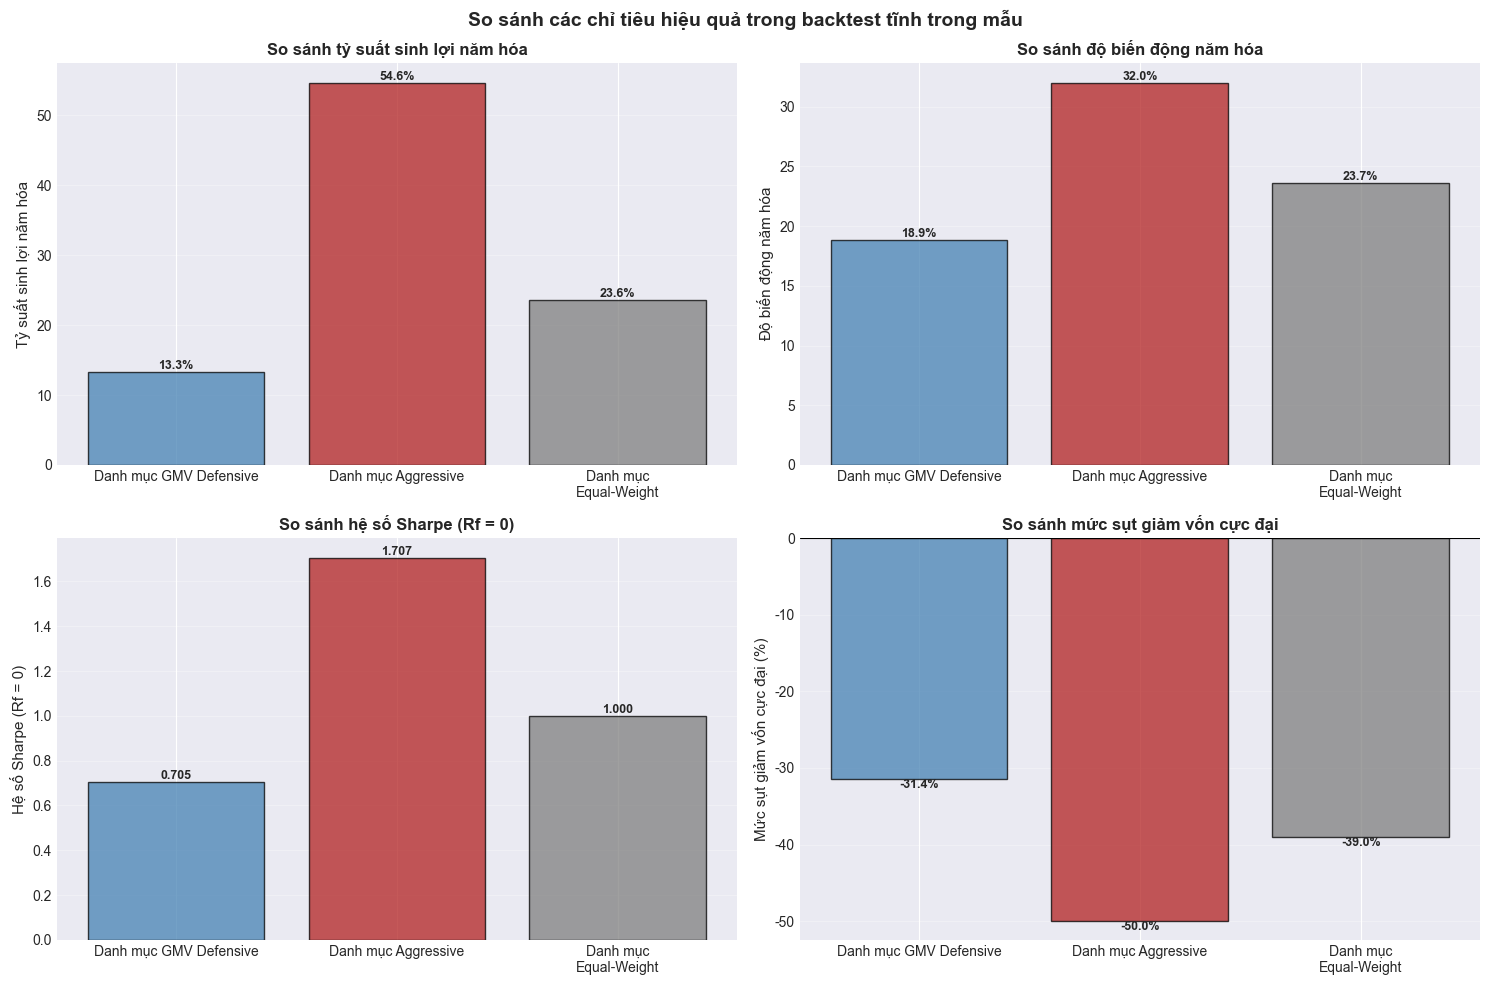

Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\backtest_static\figures\static_metrics_comparison.png


In [11]:
metrics_comparison_path = REPORTS_BACKTEST_STATIC_FIG / "static_metrics_comparison.png"

metric_entries = [
    ("Danh mục GMV Defensive", metrics_gmv, "steelblue"),
]
if metrics_agg is not None:
    metric_entries.append(("Danh mục Aggressive\n(LEGACY)" if agg_mode == "legacy" else "Danh mục Aggressive", metrics_agg, "firebrick"))
metric_entries.append(("Danh mục\nEqual-Weight", metrics_eq, "gray"))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metric_specs = [
    ("Annualized Mean Return (%)", "Tỷ suất sinh lợi năm hóa", "So sánh tỷ suất sinh lợi năm hóa"),
    ("Annualized Volatility (%)", "Độ biến động năm hóa", "So sánh độ biến động năm hóa"),
    ("Sharpe Ratio (Rf=0)", "Hệ số Sharpe (Rf = 0)", "So sánh hệ số Sharpe (Rf = 0)"),
    ("Max Drawdown (%)", "Mức sụt giảm vốn cực đại (%)", "So sánh mức sụt giảm vốn cực đại"),
]

for ax, (metric_key, display_ylabel, display_title) in zip(axes.flat, metric_specs):
    values = [entry[1][metric_key] for entry in metric_entries]
    labels = [entry[0] for entry in metric_entries]
    colors = [entry[2] for entry in metric_entries]
    bars = ax.bar(labels, values, color=colors, alpha=0.75, edgecolor="black")
    ax.set_ylabel(display_ylabel, fontsize=11)
    ax.set_title(display_title, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    if metric_key == "Max Drawdown (%)":
        ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
    for bar in bars:
        height = bar.get_height()
        text = f"{height:.1f}%" if metric_key != "Sharpe Ratio (Rf=0)" else f"{height:.3f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            text,
            ha="center",
            va="top" if metric_key == "Max Drawdown (%)" and height < 0 else "bottom",
            fontsize=9,
            fontweight="bold",
        )

fig.suptitle("So sánh các chỉ tiêu hiệu quả trong backtest tĩnh trong mẫu", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(metrics_comparison_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {metrics_comparison_path}")


## Step 8: Final Summary and Handoff

Final interpretation rules for this notebook:
- `GMV / Defensive` is the current canonical static optimizer output under notebook 06.
- `Aggressive` remains a **legacy artifact** if it is shown here.
- `Equal-Weight` is the benchmark on the same universe, frequency, and time window.
- All results remain **in-sample** and should be treated as a baseline before notebook 08.


In [12]:
print("=" * 88)
print("FINAL SUMMARY AND HANDOFF")
print("=" * 88)

print("\nNotebook role:")
print("- In-sample static portfolio backtest")
print("- Baseline evaluation after static optimization")
print("- Interpretive step before rolling / out-of-sample notebook 08")

print("\nInputs used:")
print("- return_matrix_clean.csv")
print("- portfolio_weights_static.csv")
if weights_agg is not None:
    print("- portfolio_weights_aggressive.csv")
else:
    print("- portfolio_weights_aggressive.csv (unavailable under current manifest/policy)")

print("\nCanonical baseline result:")
print(f"- {GMV_LABEL}: {metrics_df.loc[GMV_LABEL, 'Artifact Status']}")
print(f"- Clean weight validation: {metrics_df.loc[GMV_LABEL, 'Clean Weight Validation']}")
print(f"- Annualized mean return: {metrics_gmv['Annualized Mean Return (%)']:.2f}%")
print(f"- Annualized volatility:  {metrics_gmv['Annualized Volatility (%)']:.2f}%")
print(f"- Sharpe (Rf=0):          {metrics_gmv['Sharpe Ratio (Rf=0)']:.4f}")
print(f"- Max drawdown:           {metrics_gmv['Max Drawdown (%)']:.2f}%")

print("\nBenchmark reference:")
print(f"- {EQ_LABEL}")
print(f"- Annualized mean return: {metrics_eq['Annualized Mean Return (%)']:.2f}%")
print(f"- Annualized volatility:  {metrics_eq['Annualized Volatility (%)']:.2f}%")
print(f"- Sharpe (Rf=0):          {metrics_eq['Sharpe Ratio (Rf=0)']:.4f}")
print(f"- Max drawdown:           {metrics_eq['Max Drawdown (%)']:.2f}%")

print("\nAggressive comparison note:")
if metrics_agg is not None:
    print(f"- {AGG_LABEL}: {metrics_df.loc[AGG_LABEL, 'Artifact Status']}")
    print(f"- Clean weight validation: {metrics_df.loc[AGG_LABEL, 'Clean Weight Validation']}")
    print(f"- Negative weights < -tol: {agg_weight_validation['n_negative_beyond_tol']}")
    print(f"- Gross exposure:          {agg_weight_validation['gross_exposure']:.4f}")
    if agg_mode == "legacy":
        print("- Aggressive is being shown as a LEGACY / non-canonical reference only.")
    else:
        print("- Aggressive is available as a canonical strategy in this run.")
else:
    print("- Aggressive unavailable under the current manifest/policy. This notebook is running in safe mode: GMV + Equal-Weight only.")

print("\nBacktest convention used in this notebook:")
print("- Asset log-returns were converted to simple returns.")
print("- Portfolio returns were computed as daily constant-weight rebalanced simple returns.")
print("- NAV was built with (1 + r_p).cumprod().")
print("- Sharpe uses Rf = 0.")

print("\nOutputs created by notebook 07:")
print("- No new canonical portfolio artifact is exported.")
print(f"- Saved figure: {REPORTS_BACKTEST_STATIC_FIG / 'static_equity_curves.png'}")
print(f"- Saved figure: {REPORTS_BACKTEST_STATIC_FIG / 'static_drawdown_curves.png'}")
print(f"- Saved figure: {REPORTS_BACKTEST_STATIC_FIG / 'static_metrics_comparison.png'}")

print("\nCaveat:")
print("- Results are in-sample and optimistic because the static weights were estimated on the same sample used for evaluation.")
print("- This notebook is a baseline, not an out-of-sample claim.")

print("\nNext notebook:")
print("- 08_backtest_rolling_markowitz.ipynb")
print("- Rolling / out-of-sample evaluation with walk-forward re-estimation")


FINAL SUMMARY AND HANDOFF

Notebook role:
- In-sample static portfolio backtest
- Baseline evaluation after static optimization
- Interpretive step before rolling / out-of-sample notebook 08

Inputs used:
- return_matrix_clean.csv
- portfolio_weights_static.csv
- portfolio_weights_aggressive.csv

Canonical baseline result:
- GMV / Defensive (Canonical): Canonical clean artifact
- Clean weight validation: PASS
- Annualized mean return: 13.30%
- Annualized volatility:  18.87%
- Sharpe (Rf=0):          0.7048
- Max drawdown:           -31.39%

Benchmark reference:
- Equal-Weight Benchmark
- Annualized mean return: 23.64%
- Annualized volatility:  23.65%
- Sharpe (Rf=0):          0.9995
- Max drawdown:           -39.02%

Aggressive comparison note:
- Aggressive (Canonical): Canonical aggressive artifact
- Clean weight validation: PASS
- Negative weights < -tol: 0
- Gross exposure:          1.0000
- Aggressive is available as a canonical strategy in this run.

Backtest convention used in th